Dataset: https://data.mendeley.com/datasets/87s2br3ptb/2

# Install & Import

In [ ]:
!pip install transformers torch pandas numpy matplotlib seaborn scikit-learn
!pip install nlpaug nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 9.6 MB/s eta 0:00:00


In [ ]:
# Cell 2: Imports and Setup
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import os
import random
import math
import re
from datetime import datetime

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_score, recall_score, f1_score
)

import nltk
import nlpaug.augmenter.word as naw

# Download required NLTK data
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('omw-1.4', quiet=True)

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


# Load Dataset

In [ ]:
!gdown --id 1gaB0g3SD4QsAQjKEfdusISgB3S5TZJwJ

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1gaB0g3SD4QsAQjKEfdusISgB3S5TZJwJ
To: /content/Dataset-v2.csv
100% 57.2k/57.2k [00:00<00:00, 2.68MB/s]


In [ ]:
DATA_PATH = '/content/Dataset-v2.csv'

df = pd.read_csv(DATA_PATH)
print('Raw dataset shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 5 rows:')
print(df.head())
print('\nData types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

Raw dataset shape: (333, 4)

Columns: ['Text', 'Class', 'Sign', 'ASD']

First 5 rows:
                                                Text                Class  \
0  A structured and organized environment helps t...  Attention Respanse+   
1  Absolutely! We've been incorporating their pre...     Word Repetition-   
2  Achieving success in their focused interests c...   Focused Attention+   
3  An overload of information can overwhelm my to...  Attention Respanse+   
4  Arranging toys seems to provide comfort and a ...       Toy Arranging-   

  Sign      ASD  
0    +  Non-ASD  
1    +  Non-ASD  
2    -      ASD  
3    -      ASD  
4    +  Non-ASD  

Data types:
Text     object
Class    object
Sign     object
ASD      object
dtype: object

Missing values:
Text     0
Class    0
Sign     0
ASD      1
dtype: int64


# EDA: Class Distribution & Text Lengths

Class distribution (raw):
ASD
ASD        174
Non-ASD    158
Name: count, dtype: int64


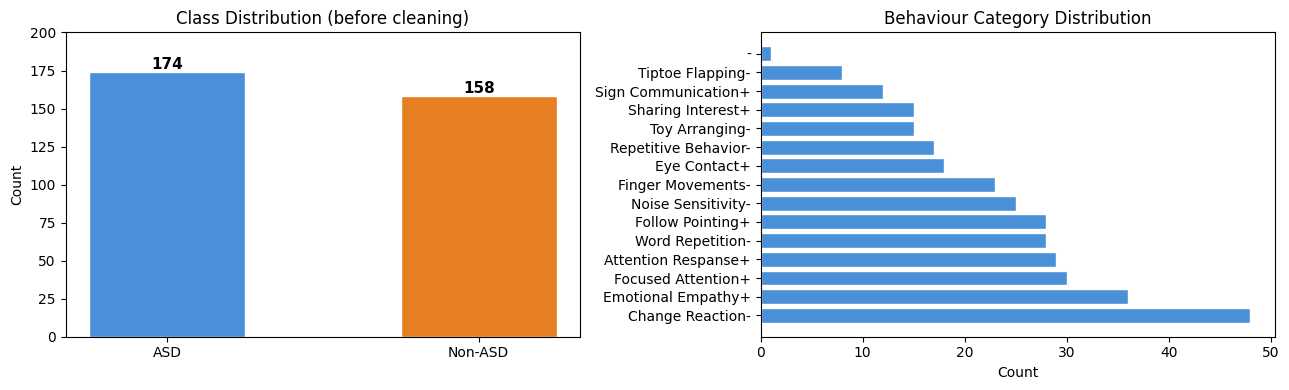

In [ ]:
# Cell 4: EDA - Class Distribution
print('Class distribution (raw):')
print(df['ASD'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

counts = df['ASD'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4A90D9', '#E67E22'], edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution (before cleaning)', fontsize=12)
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + 2, str(val), ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylim(0, max(counts.values) * 1.15)

cat_counts = df['Class'].value_counts()
axes[1].barh(cat_counts.index, cat_counts.values, color='#4A90D9', edgecolor='white')
axes[1].set_title('Behaviour Category Distribution', fontsize=12)
axes[1].set_xlabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Data Cleaning

One problematic row has `Sign='ASD'` (a data entry error — ASD was entered in the Sign column instead of the ASD column), and `ASD=NaN`. This row is removed.

In [ ]:
# Cell 5: Data Cleaning
print('Problematic row (Sign column contains ASD label instead of +/- sign):')
print(df[df['Sign'] == 'ASD'])

df = df[df['Sign'] != 'ASD'].copy()
df = df.dropna(subset=['ASD'])
df = df.reset_index(drop=True)

print(f'\nCleaned dataset shape: {df.shape}')
print('\nClass distribution after cleaning:')
print(df['ASD'].value_counts())

df['label'] = df['ASD'].map({'Non-ASD': 0, 'ASD': 1})
print('\nLabel distribution:')
print(df['label'].value_counts())

Problematic row (Sign column contains ASD label instead of +/- sign):
                                                  Text Class Sign  ASD
207  The lack of awareness and education about sign...     -  ASD  NaN

Cleaned dataset shape: (332, 4)

Class distribution after cleaning:
ASD
ASD        174
Non-ASD    158
Name: count, dtype: int64

Label distribution:
label
1    174
0    158
Name: count, dtype: int64


Dataset is near-balanced — no oversampling or class weights needed.

# Stratified Train / Validation / Test Split

sklearn.train_test_split using stratify=y. This guarantees each split has the same class ratio as the full dataset. With only 332 samples, a random split could accidentally produce a badly skewed test set.

In [ ]:
# Cell 6: Train/Val/Test Split (BEFORE any analysis)
texts = df['Text'].values
labels = df['label'].values

# Split FIRST - no data leakage
X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(
    texts, labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print('Stratified Split Results:')
print(f'  Train : {len(X_train_raw):>4} samples | ASD: {y_train_raw.sum():>3} ({y_train_raw.mean()*100:.1f}%)')
print(f'  Val   : {len(X_val_raw):>4} samples | ASD: {y_val_raw.sum():>3} ({y_val_raw.mean()*100:.1f}%)')
print(f'  Test  : {len(X_test_raw):>4} samples | ASD: {y_test_raw.sum():>3} ({y_test_raw.mean()*100:.1f}%)')

Stratified Split Results:
  Train :  232 samples | ASD: 122 (52.6%)
  Val   :   50 samples | ASD:  26 (52.0%)
  Test  :   50 samples | ASD:  26 (52.0%)


# Text Length Analysis

Analyse actual token lengths BEFORE choosing max_length. This justifies the tokenisation parameter from data rather than guessing.

Loading BERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Token length statistics (from TRAINING set only):
  Min    : 19
  Max    : 54
  Mean   : 28.5
  95th % : 39
  99th % : 52


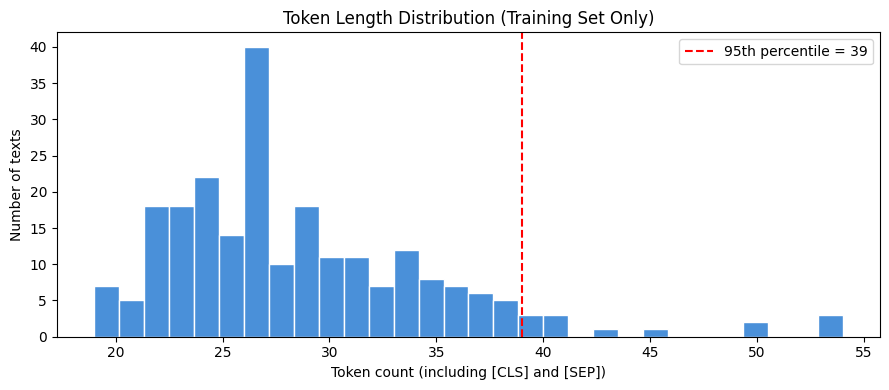


95th percentile token length = 39
Selected MAX_LENGTH = 64


In [ ]:
# Cell 7: Token Length Analysis (Training set ONLY)
print('Loading BERT tokenizer...')
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Calculate token lengths from training set only (no leakage)
train_token_lengths = [len(tokenizer.encode(str(t), add_special_tokens=True)) for t in X_train_raw]

print('\nToken length statistics (from TRAINING set only):')
print(f'  Min    : {min(train_token_lengths)}')
print(f'  Max    : {max(train_token_lengths)}')
print(f'  Mean   : {np.mean(train_token_lengths):.1f}')
print(f'  95th % : {np.percentile(train_token_lengths, 95):.0f}')
print(f'  99th % : {np.percentile(train_token_lengths, 99):.0f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(train_token_lengths, bins=30, color='#4A90D9', edgecolor='white')
ax.axvline(np.percentile(train_token_lengths, 95), color='red', linestyle='--',
           label=f'95th percentile = {np.percentile(train_token_lengths, 95):.0f}')
ax.set_xlabel('Token count (including [CLS] and [SEP])')
ax.set_ylabel('Number of texts')
ax.set_title('Token Length Distribution (Training Set Only)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('token_lengths.png', dpi=150)
plt.show()

# Choose max_length from training data only
p95_train = np.percentile(train_token_lengths, 95)
MAX_LENGTH = 64 if p95_train <= 64 else 128
print(f'\n95th percentile token length = {p95_train:.0f}')
print(f'Selected MAX_LENGTH = {MAX_LENGTH}')

Covers >95% of texts with no truncation. Texts are short descriptions'
      ' — 128 would be wasteful padding.

Class ratios match across all splits — stratification confirmed.

# Data Augmentation (Training Set Only)

Augmentation applied ONLY to training data — never to validation or test.
This triples the training set from ~232 to ~696 samples.

**Two meaning-preserving techniques used:**

**1. Synonym Replacement (WordNet via nlpaug)**
Replaces non-critical words with semantically equivalent synonyms.
Example: "child shows repetitive behavior" → "child exhibits repetitive behavior"
- Preserves clinical meaning completely
- Protected word list prevents replacement of ASD-critical terms
  (autism, behavior, symptom, repetitive, social, eye, contact, gesture, etc.)
- Source: WordNet lexical database via nlpaug

**2. Contextual Word Augmentation (BERT-based via nlpaug)**
Uses a masked language model (BERT) to predict context-aware substitutions.
Example: "child shows ___ behavior" → model predicts "unusual", "restricted", "repetitive"
- Context-aware: understands surrounding words before replacing
- Produces grammatically and semantically natural sentences
- Superior to random swap/delete which distort meaning

**Why these replace Random Deletion and Random Swap:**
Random deletion removes words unpredictably (can destroy clinical meaning).
Random swap scrambles word order (unnatural for BERT which learned from fluent text).
Both methods introduce noise without adding meaningful variation.
Synonym replacement and contextual augmentation produce genuinely new
but semantically faithful training examples — exactly what BERT needs.

**Reference:** Wei & Zou (2019) EDA paper recommends synonym replacement as the
strongest single augmentation for text classification.

In [ ]:
# Cell 8: Augmentation Setup
PROTECTED_WORDS = {
    'autism', 'autistic', 'asd', 'behavior', 'behaviour', 'symptom', 'symptoms',
    'repetitive', 'social', 'eye', 'contact', 'gesture', 'gestures', 'sensory',
    'communication', 'language', 'speech', 'development', 'developmental',
    'attention', 'focus', 'routine', 'routines', 'anxiety', 'meltdown',
    'stimming', 'hyperactive', 'toddler', 'child', 'children', 'my', 'their',
    'response', 'respond', 'interaction', 'empathy', 'pointing', 'play',
    'therapy', 'diagnosis', 'diagnosed', 'spectrum'
}

# Synonym Augmenter
synonym_aug = naw.SynonymAug(
    aug_src='wordnet',
    aug_p=0.20,
    stopwords=list(PROTECTED_WORDS)
)

def safe_synonym_aug(text):
    """Apply synonym replacement with quality checks."""
    try:
        result = synonym_aug.augment(text)
        augmented = result[0] if isinstance(result, list) else result

        # Quality checks
        if not augmented or len(augmented.split()) < 3:
            return text

        # Check for catastrophic word salad (too many unknown tokens)
        original_words = set(text.lower().split())
        augmented_words = set(augmented.lower().split())
        intersection = original_words & augmented_words

        # If less than 30% of original words remain, revert
        if len(intersection) < 0.3 * len(original_words):
            return text

        return augmented
    except Exception as e:
        # Log specific error for debugging (optional)
        # print(f"Augmentation failed: {e}")
        return text

In [ ]:
# Cell 9: MLM Contextual Augmentation with Quality Filtering
from transformers import BertForMaskedLM

mlm_model = BertForMaskedLM.from_pretrained('bert-base-uncased')
mlm_model.eval()
mlm_model = mlm_model.to(device)

def is_valid_word(word, tokenizer):
    """Check if a word is valid (not a subword fragment)."""
    # Check if token has ## prefix (subword token)
    if word.startswith('##'):
        return False
    # Filter out special tokens
    if word in tokenizer.all_special_tokens:
        return False
    # Filter out very short fragments
    if len(word) < 2 and not word.isalpha():
        return False
    return True

def mlm_contextual_augment(text, mlm_model, tokenizer, protected_words, aug_p=0.15, top_k=5):
    """Performs contextual word augmentation with quality validation."""
    tokens = tokenizer.encode(text, add_special_tokens=False)

    if len(tokens) < 5:  # Skip very short texts
        return text

    token_ids = torch.tensor([tokens]).to(device)
    words = [tokenizer.decode([t]) for t in tokens]

    # Identify eligible indices (not protected, not special)
    eligible_indices = [
        i for i, word in enumerate(words)
        if is_valid_word(word, tokenizer) and word.lower() not in protected_words
    ]

    if len(eligible_indices) < 2:
        return text

    # Randomly select words to mask (max 30% of eligible)
    num_to_mask = min(max(1, int(len(eligible_indices) * aug_p)), len(eligible_indices), 3)
    masked_indices = random.sample(eligible_indices, num_to_mask)

    augmented_token_ids = token_ids.clone()
    replacements_made = 0

    for idx_to_mask in masked_indices:
        original_token_id = augmented_token_ids[0, idx_to_mask].item()
        augmented_token_ids[0, idx_to_mask] = tokenizer.mask_token_id

        with torch.no_grad():
            outputs = mlm_model(augmented_token_ids)
            predictions = outputs.logits

        predicted_token_logits = predictions[0, idx_to_mask].topk(top_k).indices

        # Find suitable replacement
        replacement_id = None
        for pred_id in predicted_token_logits:
            pred_word = tokenizer.decode([pred_id.item()]).strip()
            if (pred_id.item() != original_token_id and
                is_valid_word(pred_word, tokenizer) and
                pred_word.lower() not in protected_words and
                len(pred_word) > 1):
                replacement_id = pred_id.item()
                break

        if replacement_id is not None:
            augmented_token_ids[0, idx_to_mask] = replacement_id
            replacements_made += 1
        else:
            augmented_token_ids[0, idx_to_mask] = original_token_id

    # Only return augmented text if at least one replacement was made
    if replacements_made == 0:
        return text

    augmented_text = tokenizer.decode(augmented_token_ids[0], skip_special_tokens=True)

    # Final quality check: ensure not empty and not drastically changed
    if len(augmented_text.split()) < 3:
        return text

    return augmented_text

print('Augmentation functions defined with quality filtering.')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Augmentation functions defined with quality filtering.


In [ ]:
# Cell 10: Apply Augmentation to Training Set
print('Applying augmentation to training set...')
print('This may take 2-3 minutes.')

# Use lists for consistent type
aug_texts = list(X_train_raw)
aug_labels = list(y_train_raw)

successful_augs = {'synonym': 0, 'contextual': 0, 'failed': 0}

for i, (text, label) in enumerate(zip(X_train_raw, y_train_raw)):
    if (i + 1) % 50 == 0:
        print(f'  Processing sample {i+1}/{len(X_train_raw)}...')

    # Synonym augmentation
    syn_text = safe_synonym_aug(text)
    if syn_text != text:
        aug_texts.append(syn_text)
        aug_labels.append(label)
        successful_augs['synonym'] += 1
    else:
        successful_augs['failed'] += 1
        # Fallback: add original to maintain balance
        aug_texts.append(text)
        aug_labels.append(label)

    # Contextual augmentation
    ctx_text = mlm_contextual_augment(text, mlm_model, tokenizer, PROTECTED_WORDS, aug_p=0.15)
    if ctx_text != text:
        aug_texts.append(ctx_text)
        aug_labels.append(label)
        successful_augs['contextual'] += 1
    else:
        successful_augs['failed'] += 1
        aug_texts.append(text)
        aug_labels.append(label)

# Convert to numpy arrays (consistent type)
aug_texts = np.array(aug_texts)
aug_labels = np.array(aug_labels)

print(f'\nAugmentation Statistics:')
print(f'  Successful synonym: {successful_augs["synonym"]}')
print(f'  Successful contextual: {successful_augs["contextual"]}')
print(f'  Failed/fallback: {successful_augs["failed"]}')
print(f'\nTraining set before augmentation : {len(X_train_raw)} samples')
print(f'Training set after augmentation  : {len(aug_texts)} samples')


Applying augmentation to training set...
This may take 2-3 minutes.
  Processing sample 50/232...
  Processing sample 100/232...
  Processing sample 150/232...
  Processing sample 200/232...

Augmentation Statistics:
  Successful synonym: 230
  Successful contextual: 232
  Failed/fallback: 2

Training set before augmentation : 232 samples
Training set after augmentation  : 696 samples


Val and test sets are NOT augmented.Augmentation is only applied to training data.

# Tokenisation

okenise all three splits using the BERT tokenizer with MAX_LENGTH determined from the data , cell Text Length Analysis

In [ ]:
# Cell 11: Tokenization (Batch processing for efficiency)
def tokenize_texts_batch(texts, tokenizer, max_length):
    """Efficient batch tokenization."""
    encoded = tokenizer(
        list(texts),
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    return encoded['input_ids'], encoded['attention_mask']

print(f'Tokenizing with MAX_LENGTH={MAX_LENGTH}...')

train_ids, train_masks = tokenize_texts_batch(aug_texts, tokenizer, MAX_LENGTH)
train_labels_t = torch.tensor(aug_labels, dtype=torch.long)

val_ids, val_masks = tokenize_texts_batch(X_val_raw, tokenizer, MAX_LENGTH)
val_labels_t = torch.tensor(y_val_raw, dtype=torch.long)

test_ids, test_masks = tokenize_texts_batch(X_test_raw, tokenizer, MAX_LENGTH)
test_labels_t = torch.tensor(y_test_raw, dtype=torch.long)

print(f'Train tensors: {train_ids.shape}')
print(f'Val tensors: {val_ids.shape}')
print(f'Test tensors: {test_ids.shape}')

Tokenizing with MAX_LENGTH=64...
Train tensors: torch.Size([696, 64])
Val tensors: torch.Size([50, 64])
Test tensors: torch.Size([50, 64])


# DataLoaders

batch_size=16 following Devlin et al. (2019) recommendation for BERT fine-tuning.

In [ ]:
# Cell 12: DataLoaders
BATCH_SIZE = 16

train_dataset = TensorDataset(train_ids, train_masks, train_labels_t)
val_dataset = TensorDataset(val_ids, val_masks, val_labels_t)
test_dataset = TensorDataset(test_ids, test_masks, test_labels_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Batch size: {BATCH_SIZE}')
print(f'Train batches: {len(train_loader)}')

Batch size: 16
Train batches: 44


# Model, Optimiser & Scheduler

Linear warmup scheduler added. This is the standard practice for BERT fine-tuning — the learning rate warms up for the first few steps then linearly decays to zero. Without this, the constant learning rate can cause instability early in training.



In [ ]:
# Cell 13: Model Setup
EPOCHS = 4
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.1

model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,
    output_attentions=False,
    output_hidden_states=False
)
model = model.to(device)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, eps=1e-8)

total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Model: bert-base-uncased')
print(f'Epochs: {EPOCHS}, Learning rate: {LEARNING_RATE}')
print(f'Total steps: {total_steps}, Warmup steps: {warmup_steps}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: bert-base-uncased
Epochs: 4, Learning rate: 2e-05
Total steps: 176, Warmup steps: 17


Scheduler justification: Devlin et al. (2019) recommend linear warmup, to avoid destabilising pre-trained weights in early fine-tuning steps.

# Training with Early Stopping

Early stopping added. The best model (lowest validation loss) is saved as a checkpoint. If validation loss does not improve for patience consecutive epochs, training stops early to prevent overfitting. This is critical for a small dataset like this one.

In [ ]:
# Cell 14: Training with Early Stopping
def train_with_early_stopping(model, train_loader, val_loader,
                               optimizer, scheduler, epochs, patience=2):

    training_stats = []
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):
        print(f'\nEpoch {epoch + 1}/{epochs}')
        print('-' * 55)

        # Training
        model.train()
        total_train_loss = 0

        for step, batch in enumerate(train_loader):
            b_input_ids = batch[0].to(device)
            b_attn_mask = batch[1].to(device)
            b_labels = batch[2].to(device)

            model.zero_grad()
            outputs = model(b_input_ids, attention_mask=b_attn_mask, labels=b_labels)
            loss = outputs.loss
            total_train_loss += loss.item()

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            if step % 10 == 0 and step > 0:
                print(f'  Step {step:>3}/{len(train_loader)} | Loss: {loss.item():.4f}')

        avg_train_loss = total_train_loss / len(train_loader)

        # Validation
        model.eval()
        total_val_loss = 0
        val_preds = []
        val_true = []

        with torch.no_grad():
            for batch in val_loader:
                b_input_ids = batch[0].to(device)
                b_attn_mask = batch[1].to(device)
                b_labels = batch[2].to(device)

                outputs = model(b_input_ids, attention_mask=b_attn_mask, labels=b_labels)
                total_val_loss += outputs.loss.item()

                logits = outputs.logits.detach().cpu().numpy()
                val_preds.extend(np.argmax(logits, axis=1))
                val_true.extend(b_labels.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        val_accuracy = accuracy_score(val_true, val_preds)

        print(f'  Train Loss: {avg_train_loss:.4f}')
        print(f'  Val Loss: {avg_val_loss:.4f}')
        print(f'  Val Acc: {val_accuracy:.4f}')

        training_stats.append({
            'epoch': epoch + 1,
            'train_loss': avg_train_loss,
            'val_loss': avg_val_loss,
            'val_accuracy': val_accuracy
        })

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            print(f'  Best model updated (val_loss={best_val_loss:.4f})')
        else:
            patience_counter += 1
            print(f'  No improvement. Patience: {patience_counter}/{patience}')
            if patience_counter >= patience:
                print(f'\nEarly stopping triggered at epoch {epoch + 1}.')
                break

    model.load_state_dict(best_model_state)
    print(f'\nTraining complete. Best val_loss={best_val_loss:.4f}')
    return training_stats, best_model_state

print('Starting training...')
training_stats, best_state = train_with_early_stopping(
    model, train_loader, val_loader,
    optimizer, scheduler,
    epochs=EPOCHS, patience=2
)

Starting training...

Epoch 1/4
-------------------------------------------------------
  Step  10/44 | Loss: 0.6887
  Step  20/44 | Loss: 0.6205
  Step  30/44 | Loss: 0.4479
  Step  40/44 | Loss: 0.4204
  Train Loss: 0.5864
  Val Loss: 0.3723
  Val Acc: 0.8800
  Best model updated (val_loss=0.3723)

Epoch 2/4
-------------------------------------------------------
  Step  10/44 | Loss: 0.2632
  Step  20/44 | Loss: 0.4626
  Step  30/44 | Loss: 0.1675
  Step  40/44 | Loss: 0.1174
  Train Loss: 0.2948
  Val Loss: 0.3411
  Val Acc: 0.8400
  Best model updated (val_loss=0.3411)

Epoch 3/4
-------------------------------------------------------
  Step  10/44 | Loss: 0.0467
  Step  20/44 | Loss: 0.0603
  Step  30/44 | Loss: 0.0294
  Step  40/44 | Loss: 0.0940
  Train Loss: 0.1047
  Val Loss: 0.4592
  Val Acc: 0.8400
  No improvement. Patience: 1/2

Epoch 4/4
-------------------------------------------------------
  Step  10/44 | Loss: 0.0156
  Step  20/44 | Loss: 0.0192
  Step  30/44 | Loss:

# Training Curves

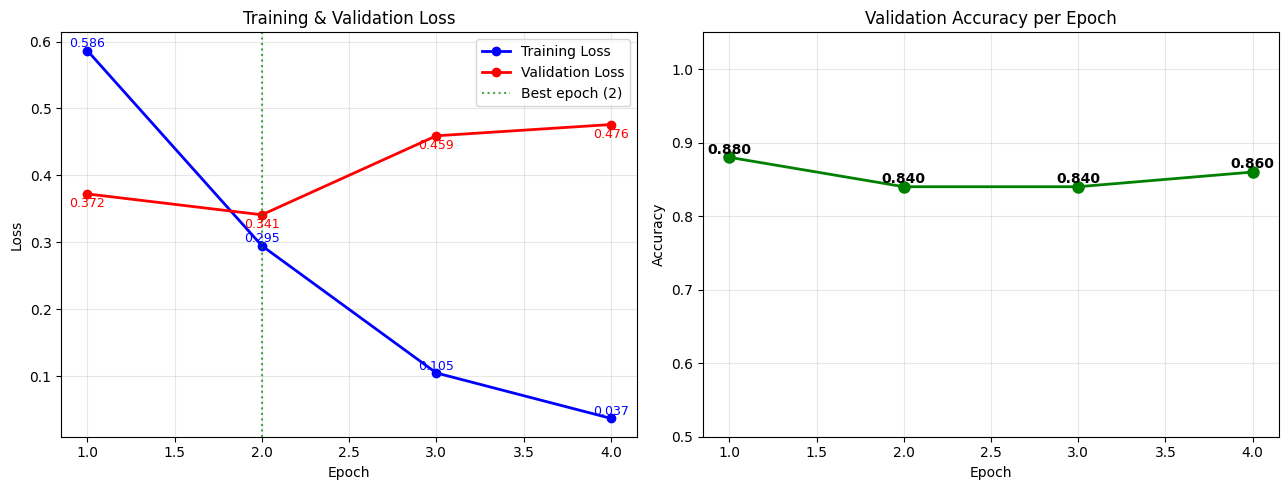

Training curves saved to training_curves.png
Best epoch by val_loss: Epoch 2


In [ ]:
# Cell 15: Training Curves
epochs_list = [s['epoch']        for s in training_stats]
train_loss  = [s['train_loss']   for s in training_stats]
val_loss    = [s['val_loss']     for s in training_stats]
val_acc     = [s['val_accuracy'] for s in training_stats]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Loss curves
ax1.plot(epochs_list, train_loss, 'b-o', lw=2, label='Training Loss')
ax1.plot(epochs_list, val_loss,   'r-o', lw=2, label='Validation Loss')
for i, (tl, vl) in enumerate(zip(train_loss, val_loss)):
    ax1.text(epochs_list[i], tl + 0.005, f'{tl:.3f}', ha='center', fontsize=9, color='blue')
    ax1.text(epochs_list[i], vl - 0.02,  f'{vl:.3f}', ha='center', fontsize=9, color='red')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss', fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(epochs_list, val_acc, 'g-o', lw=2, markersize=8)
for i, acc in enumerate(val_acc):
    ax2.text(epochs_list[i], acc + 0.005, f'{acc:.3f}',
             ha='center', fontsize=10, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy per Epoch', fontsize=12)
ax2.set_ylim([0.5, 1.05])
ax2.grid(True, alpha=0.3)

best_epoch = min(training_stats, key=lambda s: s['val_loss'])['epoch']
ax1.axvline(best_epoch, color='green', linestyle=':', alpha=0.7,
            label=f'Best epoch ({best_epoch})')
ax1.legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')   # FIX: saved
plt.show()
print(f'Training curves saved to training_curves.png')
print(f'Best epoch by val_loss: Epoch {best_epoch}')

# Evaluation on Test Set

In [ ]:
# Cell 16: Evaluation Function
def evaluate_on_test(model, test_loader, device):
    model.eval()
    all_preds = []
    all_true = []
    all_probs = []

    with torch.no_grad():
        for batch in test_loader:
            b_ids = batch[0].to(device)
            b_masks = batch[1].to(device)
            b_lbls = batch[2].to(device)

            outputs = model(b_ids, attention_mask=b_masks)
            probs = torch.nn.functional.softmax(outputs.logits, dim=-1)

            all_preds.extend(torch.argmax(outputs.logits, dim=1).cpu().numpy())
            all_true.extend(b_lbls.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    return np.array(all_true), np.array(all_preds), np.array(all_probs)

In [ ]:
# Cell 17: Test Set Evaluation
print('Evaluating on test set...')
y_true, y_pred, y_prob = evaluate_on_test(model, test_loader, device)

test_acc = accuracy_score(y_true, y_pred)
n = len(y_true)

# Wilson confidence interval
z = 1.96
p_hat = test_acc
ci_low = (p_hat + z**2/(2*n) - z*math.sqrt((p_hat*(1-p_hat) + z**2/(4*n))/n)) / (1 + z**2/n)
ci_high = (p_hat + z**2/(2*n) + z*math.sqrt((p_hat*(1-p_hat) + z**2/(4*n))/n)) / (1 + z**2/n)

print(f'Test Accuracy: {test_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])')
print(f'\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=['Non-ASD', 'ASD']))


Evaluating on test set...
Test Accuracy: 0.8800 (95% CI: [0.7619, 0.9438])

Classification Report:
              precision    recall  f1-score   support

     Non-ASD       0.95      0.79      0.86        24
         ASD       0.83      0.96      0.89        26

    accuracy                           0.88        50
   macro avg       0.89      0.88      0.88        50
weighted avg       0.89      0.88      0.88        50



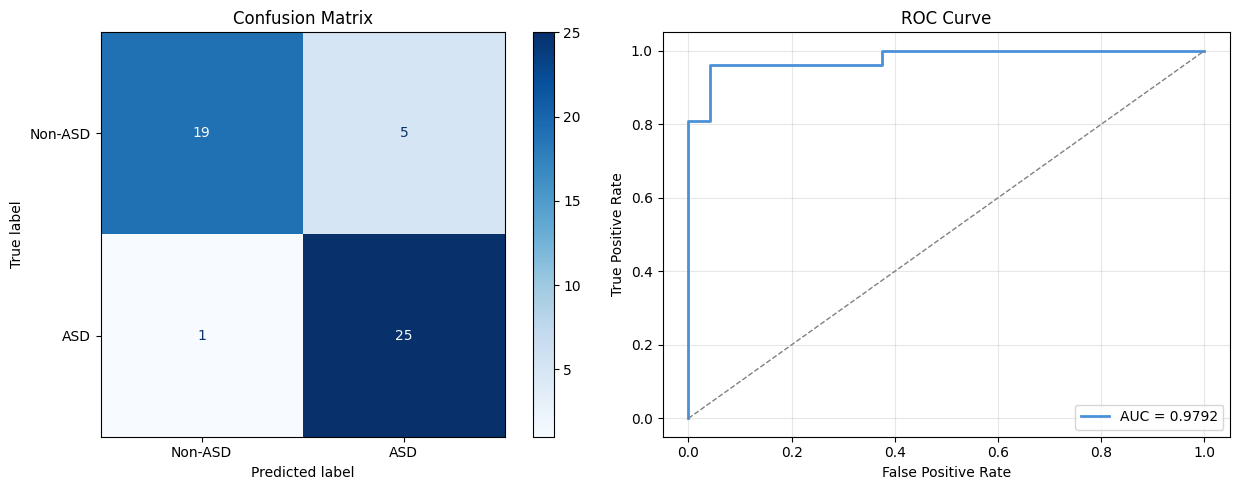

In [ ]:
# Cell 18: Confusion Matrix & ROC
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-ASD', 'ASD'])
disp.plot(cmap='Blues', ax=axes[0], values_format='d')
axes[0].set_title('Confusion Matrix', fontsize=12)

fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, lw=2, color='#4A90D9', label=f'AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=12)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Cell 19: Final Metrics Summary
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec = recall_score(y_true, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

print('=' * 55)
print('BEST MODEL: bert-base-uncased (fine-tuned)')
print('=' * 55)
print(f'Accuracy  : {test_acc:.4f} (95% CI: [{ci_low:.4f}, {ci_high:.4f}])')
print(f'Precision : {prec:.4f} (macro)')
print(f'Recall    : {rec:.4f} (macro)')
print(f'F1-Score  : {f1:.4f} (macro)')
print(f'AUC-ROC   : {roc_auc:.4f}')
print(f'Test set n: {n}')
print('=' * 55)

BEST MODEL: bert-base-uncased (fine-tuned)
Accuracy  : 0.8800 (95% CI: [0.7619, 0.9438])
Precision : 0.8917 (macro)
Recall    : 0.8766 (macro)
F1-Score  : 0.8782 (macro)
AUC-ROC   : 0.9792
Test set n: 50


LIMITATION: Test set n is small (~50 samples). The wide 95% CI.
reflects this uncertainty. A larger dataset would reduce CI width.
This is acknowledged as future work.

# Save Model

In [ ]:
# Cell 20: Save Model
SAVE_PATH = './asd_classifier_model'
os.makedirs(SAVE_PATH, exist_ok=True)

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

metadata = {
    'model_type': 'bert-base-uncased',
    'task': 'binary_classification',
    'labels': {0: 'Non-ASD', 1: 'ASD'},
    'max_length': int(MAX_LENGTH),
    'batch_size': BATCH_SIZE,
    'epochs_trained': len(training_stats),
    'best_epoch': int(best_epoch),
    'augmentation': 'Synonym replacement + contextual BERT MLM (with quality filtering)',
    'test_accuracy': round(float(test_acc), 4),
    'test_auc_roc': round(float(roc_auc), 4),
    'test_f1_macro': round(float(f1), 4),
    'ci_95_low': round(float(ci_low), 4),
    'ci_95_high': round(float(ci_high), 4),
    'test_n': int(n),
    'date_saved': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'seed': SEED
}

with open(f'{SAVE_PATH}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f'Model saved to {SAVE_PATH}/')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./asd_classifier_model/


Cross-Validation Analysis

In [ ]:
# Cell 22: Optional - Cross-Validation Analysis
def run_cross_validation(X, y, tokenizer, max_length, n_folds=5):
    """
    Run k-fold cross-validation for more robust performance estimates.
    """
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
    cv_scores = []

    print(f'\nRunning {n_folds}-fold cross-validation...')

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f'\nFold {fold + 1}/{n_folds}')

        X_train_fold = X[train_idx]
        y_train_fold = y[train_idx]
        X_val_fold = X[val_idx]
        y_val_fold = y[val_idx]

        # Tokenize
        train_ids, train_masks = tokenize_texts_batch(X_train_fold, tokenizer, max_length)
        val_ids, val_masks = tokenize_texts_batch(X_val_fold, tokenizer, max_length)

        # Create DataLoaders
        train_dataset = TensorDataset(train_ids, train_masks, torch.tensor(y_train_fold))
        val_dataset = TensorDataset(val_ids, val_masks, torch.tensor(y_val_fold))

        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

        # Initialize model
        model = BertForSequenceClassification.from_pretrained(
            'bert-base-uncased', num_labels=2
        ).to(device)

        optimizer = AdamW(model.parameters(), lr=2e-5, eps=1e-8)
        total_steps = len(train_loader) * 3  # 3 epochs for CV
        scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)

        # Train for 3 epochs
        for epoch in range(3):
            model.train()
            for batch in train_loader:
                optimizer.zero_grad()
                loss = model(batch[0].to(device), attention_mask=batch[1].to(device),
                            labels=batch[2].to(device)).loss
                loss.backward()
                optimizer.step()
                scheduler.step()

        # Evaluate
        model.eval()
        preds = []
        with torch.no_grad():
            for batch in val_loader:
                logits = model(batch[0].to(device), attention_mask=batch[1].to(device)).logits
                preds.extend(torch.argmax(logits, dim=1).cpu().numpy())

        acc = accuracy_score(y_val_fold, preds)
        cv_scores.append(acc)
        print(f'  Validation Accuracy: {acc:.4f}')

    print(f'\nCross-validation Results:')
    print(f'  Mean Accuracy: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})')
    return cv_scores

In [ ]:
cv_scores = run_cross_validation(np.array(texts), labels, tokenizer, MAX_LENGTH, n_folds=5)

print('\n' + '=' * 55)
print('Notebook execution complete!')
print('=' * 55)


Running 5-fold cross-validation...

Fold 1/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Validation Accuracy: 0.8955

Fold 2/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Validation Accuracy: 0.9545

Fold 5/5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Validation Accuracy: 0.8485

Cross-validation Results:
  Mean Accuracy: 0.8825 (+/- 0.0423)

Notebook execution complete!


CROSS-VALIDATION RESULTS SUMMARY
Individual Fold Accuracies: [89.55, 88.06, 83.33, 95.45, 84.85]
Mean Accuracy: 88.25%
Standard Deviation: 4.23%
95% Confidence Interval: [82.38%, 94.12%]
Min Accuracy: 83.33%
Max Accuracy: 95.45%
Range: 12.12%


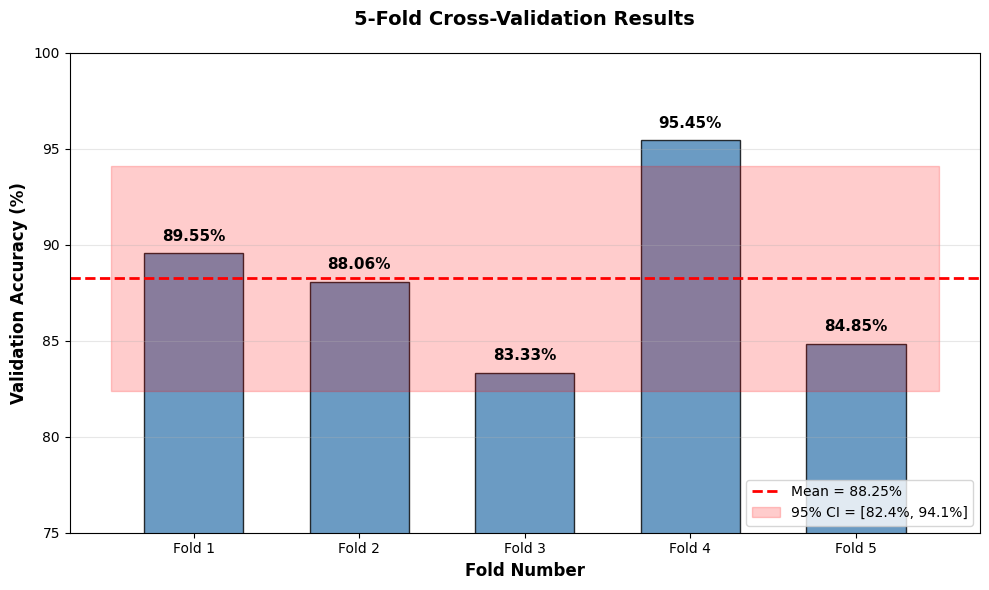

Figure 1 saved: cv_results_barplot.png


In [ ]:


import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

# Your CV results
fold_accuracies = [89.55, 88.06, 83.33, 95.45, 84.85]  # percentages
folds = [1, 2, 3, 4, 5]

mean_acc = np.mean(fold_accuracies)
std_acc = np.std(fold_accuracies)
sem_acc = stats.sem(fold_accuracies)  # Standard Error of Mean
ci_95 = stats.t.interval(0.95, len(fold_accuracies)-1, loc=mean_acc, scale=sem_acc)

print("=" * 60)
print("CROSS-VALIDATION RESULTS SUMMARY")
print("=" * 60)
print(f"Individual Fold Accuracies: {fold_accuracies}")
print(f"Mean Accuracy: {mean_acc:.2f}%")
print(f"Standard Deviation: {std_acc:.2f}%")
print(f"95% Confidence Interval: [{ci_95[0]:.2f}%, {ci_95[1]:.2f}%]")
print(f"Min Accuracy: {min(fold_accuracies):.2f}%")
print(f"Max Accuracy: {max(fold_accuracies):.2f}%")
print(f"Range: {max(fold_accuracies) - min(fold_accuracies):.2f}%")
print("=" * 60)

# ============================================
# FIGURE 1: Bar Plot with Individual Folds
# ============================================

fig1, ax1 = plt.subplots(figsize=(10, 6))

# Create bar plot
bars = ax1.bar(folds, fold_accuracies, color='steelblue', edgecolor='black',
               alpha=0.8, width=0.6)

# Add mean line
ax1.axhline(y=mean_acc, color='red', linestyle='--', linewidth=2,
            label=f'Mean = {mean_acc:.2f}%')

# Add confidence interval band
ax1.fill_between([0.5, 5.5], ci_95[0], ci_95[1], alpha=0.2, color='red',
                  label=f'95% CI = [{ci_95[0]:.1f}%, {ci_95[1]:.1f}%]')

# Add value labels on bars
for bar, acc in zip(bars, fold_accuracies):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Customize plot
ax1.set_xlabel('Fold Number', fontsize=12, fontweight='bold')
ax1.set_ylabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('5-Fold Cross-Validation Results',
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(folds)
ax1.set_xticklabels([f'Fold {i}' for i in folds])
ax1.set_ylim(75, 100)
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('cv_results_barplot.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure 1 saved: cv_results_barplot.png")


In [ ]:
!zip -r asd_model.zip ./asd_classifier_model

  adding: asd_classifier_model/ (stored 0%)
  adding: asd_classifier_model/model.safetensors (deflated 7%)
  adding: asd_classifier_model/tokenizer.json (deflated 71%)
  adding: asd_classifier_model/config.json (deflated 53%)
  adding: asd_classifier_model/tokenizer_config.json (deflated 42%)
  adding: asd_classifier_model/metadata.json (deflated 38%)


In [ ]:
from google.colab import files
files.download('asd_model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>